# 02 - Provera ispravnosti data pipeline-a

Vizuelni pratilac uz `scripts/sanity_check.py` (merodavna provera zasnovana na
assert-ima - nju pokrenite prvo; mora da se završi sa izlaznim kodom 0 pre nego što se napiše bilo kakav kod modela).

Ovde *posmatramo* pipeline: denormalizovani augmentovani batch, eval batch
i class distribution po svakom split-u. Heavy augmentation je naša glavna mera
za ublažavanje problema pristrasnosti pozadine (background-bias) kod PlantVillage-a, pa je vredno pogledati je.

In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.dataset import PlantVillageDataset
from src.data.loaders import build_dataset, build_loader
from src.data.splits import LabelMaps, load_split
from src.data.transforms import IMAGENET_MEAN, IMAGENET_STD
from src.utils.seed import seed_everything

seed_everything(42)

# Izmenite prema lokaciji vaših podataka.
DATA_ROOT = PROJECT_ROOT / "data" / "raw" / "plantvillage dataset" / "color"
SPLITS_DIR = PROJECT_ROOT / "data" / "splits"
maps = LabelMaps.from_json(SPLITS_DIR / "label_maps.json")
print("species:", maps.num_species, "| classes:", maps.num_classes)

species: 14 | classes: 38


C:\Users\Marija\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Pomoćna funkcija za denormalize

In [2]:
mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

def denorm(t: torch.Tensor) -> np.ndarray:
    img = (t * std + mean).clamp(0, 1)
    return img.permute(1, 2, 0).numpy()

## Heavy train augmentation - više izvlačenja iste slike

Ista izvorna slika, 8 augmentovanih izvlačenja. Treba znatno da variraju (crop,
flip, boja, okluzija) - upravo ta varijacija obeshrabruje memorisanje pozadine.

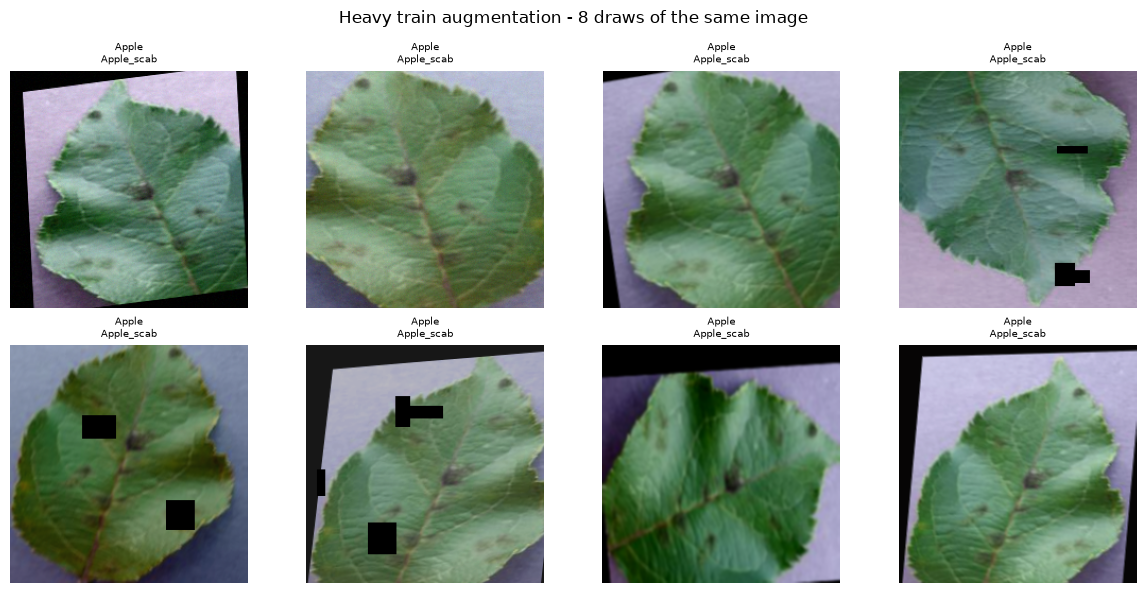

In [3]:
train_ds = build_dataset(data_root=DATA_ROOT, splits_dir=SPLITS_DIR, split="train",
                         mode="flat", img_size=224, aug_strength="heavy")
idx = 0
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax in axes.ravel():
    img, label = train_ds[idx]
    ax.imshow(denorm(img)); ax.axis("off")
    ax.set_title(maps.id_to_class[label].replace("___", "\n"), fontsize=7)
fig.suptitle("Heavy train augmentation - 8 draws of the same image")
plt.tight_layout(); plt.show()

## Eval batch (minimalna transformacija)

C:\Users\Marija\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


batch: (8, 3, 224, 224) labels: [0, 0, 0, 0, 0, 0, 0, 0]


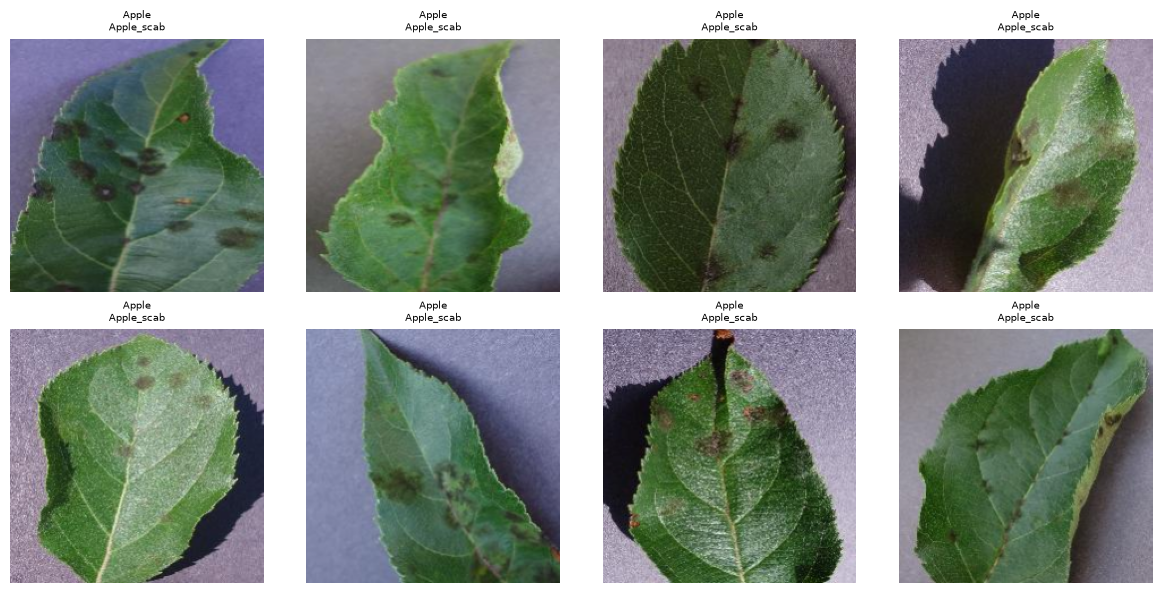

In [4]:
val_ds = build_dataset(data_root=DATA_ROOT, splits_dir=SPLITS_DIR, split="val",
                       mode="flat", img_size=224)
loader = build_loader(val_ds, batch_size=8, is_train=False, num_workers=0)
xb, yb = next(iter(loader))
print("batch:", tuple(xb.shape), "labels:", yb.tolist())

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for ax, img, label in zip(axes.ravel(), xb, yb):
    ax.imshow(denorm(img)); ax.axis("off")
    ax.set_title(maps.id_to_class[int(label)].replace("___", "\n"), fontsize=7)
plt.tight_layout(); plt.show()

## Class distribution po split-u

Potvrđuje da je stratified split zadržao stabilne proporcije kroz train/val/test.

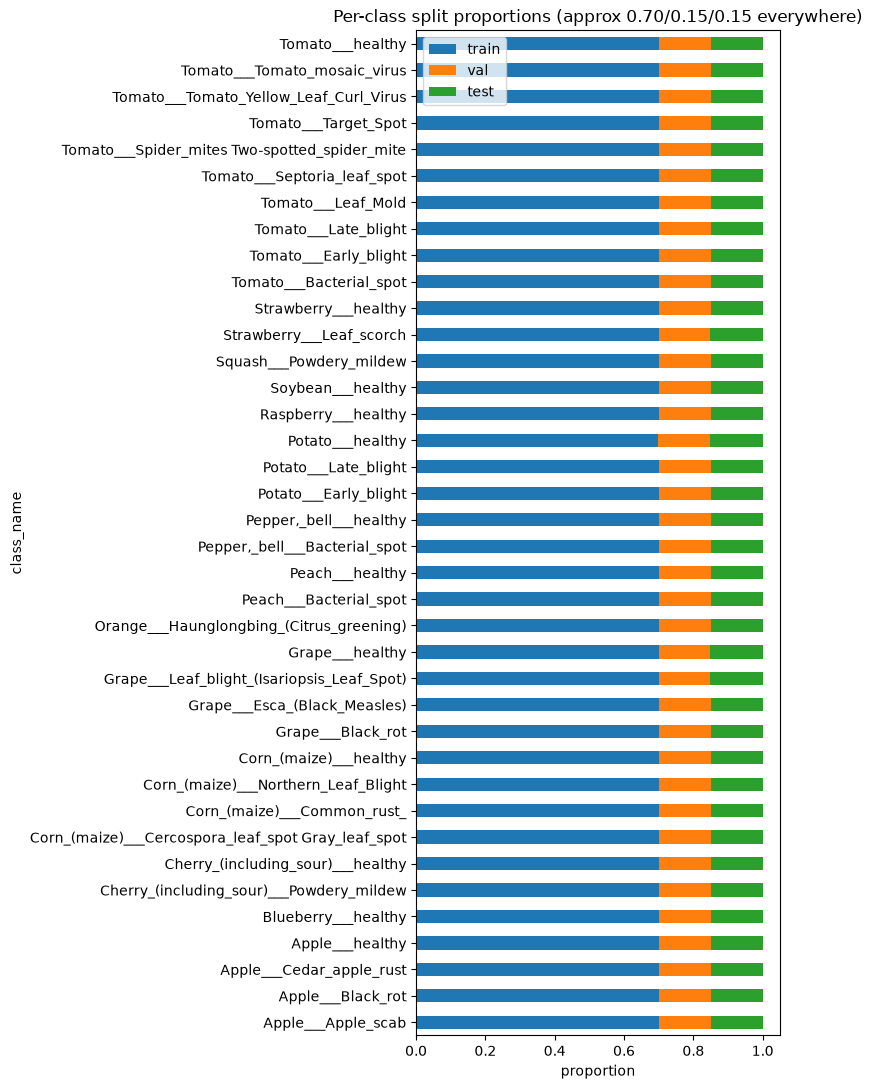

,train,val,test
mean,0.700,0.150,0.150
min,0.697,0.149,0.148
max,0.702,0.151,0.151


In [5]:
import pandas as pd
frames = {s: load_split(SPLITS_DIR, s) for s in ("train", "val", "test")}
dist = pd.DataFrame({s: f["class_name"].value_counts() for s, f in frames.items()}).fillna(0)
props = dist.div(dist.sum(axis=1), axis=0)
ax = props.sort_index().plot(kind="barh", stacked=True, figsize=(8, 11))
ax.set(title="Per-class split proportions (approx 0.70/0.15/0.15 everywhere)", xlabel="proportion")
plt.tight_layout(); plt.show()
props.describe().loc[["mean", "min", "max"]].round(3)

## Provera weighted sampler-a

Izvlačimo mnogo indeksa kroz `WeightedRandomSampler` i potvrđujemo da on izravnava
(inače ~36x) neuravnoteženost klasa ka uniformnoj.

In [6]:
from src.training.samplers import make_weighted_sampler
labels = frames["train"]["class_id"].to_numpy()
sampler = make_weighted_sampler(labels, maps.num_classes)
drawn = np.array([labels[i] for i in list(sampler)[:30000]])
orig = np.bincount(labels, minlength=maps.num_classes)
samp = np.bincount(drawn, minlength=maps.num_classes)
print(f"original imbalance: {orig.max()/orig.min():.1f}x")
print(f"sampled  imbalance: {samp.max()/max(samp.min(),1):.1f}x  (should be near 1x)")

original imbalance: 36.4x
sampled  imbalance: 1.1x  (should be near 1x)
